In [6]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

# ============================================================
#  SETUP: SMF-28 fiber @ 1550nm -> InGaAs detector (1mm)
# ============================================================
#
#  Geometry (2D cross-section):
#
#                        +z (vertical)
#                        |
#         Detector (1mm, active face DOWN)
#         ============================  z = z_det
#         x_c - d/2      x_c + d/2
#
#                 / diverging Gaussian
#                / theta (from +x axis)
#  FIBER  ==*========================> +x (horizontal)
#           (0,0)
#
#  Physics covered:
#    [1] Gaussian beam:   I(th) = exp(-2 th^2 / th0^2)
#    [2] Snell at exit:   th0 in air from n_core * sin(th_f) = sin(th_air)
#    [3] Fresnel @ fiber: glass(1.468) -> air, angle-dependent
#    [4] Geometry:        which angles [th_min, th_max] hit the detector
#    [5] Fresnel @ det:   air -> InGaAs(3.5), incidence = pi/2 - th
#    [6] Coupling:        integral of [1]*[3]*[5] over [4], normalized
#
# ============================================================

# --- Parameters ---
lam    = 1.550e-6     # wavelength [m]
w0     = 5.2e-6       # beam waist = MFD/2 for SMF-28 [m]
n_core = 1.4682       # fiber core index @ 1550nm
n_air  = 1.0          # air
n_det  = 3.5          # InGaAs detector index @ 1550nm
d      = 1.0e-3       # detector diameter = 1 mm [m]

# --- [1]+[2] Divergence angle ---
# 1/e^2 half-angle inside fiber, then Snell to air
theta_fib = lam / (np.pi * n_core * w0)                     # 3.7 deg in fiber
theta0    = np.arcsin(n_core * np.sin(theta_fib) / n_air)   # 5.4 deg in air

print(f'Beam waist w0     = {w0*1e6:.1f} um')
print(f'Divergence (fiber)= {np.degrees(theta_fib):.2f} deg')
print(f'Divergence (air)  = {np.degrees(theta0):.2f} deg  [Snell]')

# --- [3]+[5] Fresnel transmittance ---
def fresnel_T(th, n1, n2):
    """Power transmittance (unpolarized) at incidence angle th."""
    ci = np.cos(th)
    st = (n1/n2) * np.sin(th)
    if abs(st) >= 1:          # total internal reflection
        return 0.0
    ct = np.sqrt(1 - st**2)
    rs = (n1*ci - n2*ct) / (n1*ci + n2*ct)   # s-polarization
    rp = (n2*ci - n1*ct) / (n2*ci + n1*ct)   # p-polarization
    return 1 - 0.5*(rs**2 + rp**2)

print(f'Fresnel T fiber exit (normal) = {fresnel_T(0, n_core, n_air):.4f}')
print(f'Fresnel T detector   (normal) = {fresnel_T(0, n_air, n_det):.4f}')

# --- [4]+[6] Coupling function ---
def coupling(z_det, x_center):
    """
    Fraction of fiber power reaching detector at height z_det,
    centered at x_center (both in metres).
    Returns (fraction, power_dBm).
    """
    xL = x_center - d/2        # left edge of detector
    xR = x_center + d/2        # right edge
    
    # Angles from fiber tip to detector edges
    th_max = np.pi/2 if xL <= 0 else np.arctan2(z_det, xL)
    th_min = np.arctan2(z_det, xR) if xR > 0 else 0.0
    if th_min > th_max:
        th_min, th_max = th_max, th_min
    
    # Integrand: Gaussian * Fresnel_fiber_exit * Fresnel_detector
    def integrand(th):
        G     = np.exp(-2*(th/theta0)**2)              # [1] Gaussian
        T_fib = fresnel_T(th, n_core, n_air)           # [3] fiber face
        T_det = fresnel_T(np.pi/2 - th, n_air, n_det)  # [5] detector
        return G * T_fib * T_det
    
    # Normalize by total Gaussian in full forward hemisphere
    P_det, _ = quad(integrand, th_min, th_max, limit=200)
    P_tot, _ = quad(lambda th: np.exp(-2*(th/theta0)**2),
                    -np.pi/2, np.pi/2, limit=200)
    
    frac = P_det / P_tot if P_tot > 0 else 0.0
    dBm  = 10*np.log10(frac) if frac > 0 else -np.inf
    return frac, dBm

Beam waist w0     = 5.2 um
Divergence (fiber)= 3.70 deg
Divergence (air)  = 5.44 deg  [Snell]
Fresnel T fiber exit (normal) = 0.9640
Fresnel T detector   (normal) = 0.6914


In [7]:
# ============================================================
#  RESULTS TABLE
# ============================================================
print('Coupled power to 1mm InGaAs detector (0 dBm input)')
print('=' * 60)
print(f'{"z[um]":>7} {"x_c[um]":>8} {"Fraction":>13} {"dBm":>10}')
print('-' * 60)

for z_um in range(0, 1100, 100):
    for x_um in range(1000, 5500, 1000):
        f, db = coupling(z_um*1e-6, x_um*1e-6)
        db_s = f'{db:.2f}' if np.isfinite(db) else '-inf'
        f_s  = f'{f*100:.6f}%' if f >= 1e-4 else (f'{f:.2e}' if f > 0 else '~0')
        print(f'{z_um:>7} {x_um:>8} {f_s:>13} {db_s:>10}')

Coupled power to 1mm InGaAs detector (0 dBm input)
  z[um]  x_c[um]      Fraction        dBm
------------------------------------------------------------
      0     1000            ~0       -inf
      0     2000            ~0       -inf
      0     3000            ~0       -inf
      0     4000            ~0       -inf
      0     5000            ~0       -inf
    100     1000     3.202020%     -14.95
    100     2000     3.413002%     -14.67
    100     3000     1.541244%     -18.12
    100     4000     0.756403%     -21.21
    100     5000     0.417470%     -23.79
    200     1000     0.134528%     -28.71
    200     2000     1.843211%     -17.34
    200     3000     2.329289%     -16.33
    200     4000     1.689922%     -17.72
    200     5000     1.123171%     -19.50
    300     1000      9.28e-06     -50.32
    300     2000     0.293533%     -25.32
    300     3000     1.276356%     -18.94
    300     4000     1.632131%     -17.87
    300     5000     1.433488%     -18.44
    40

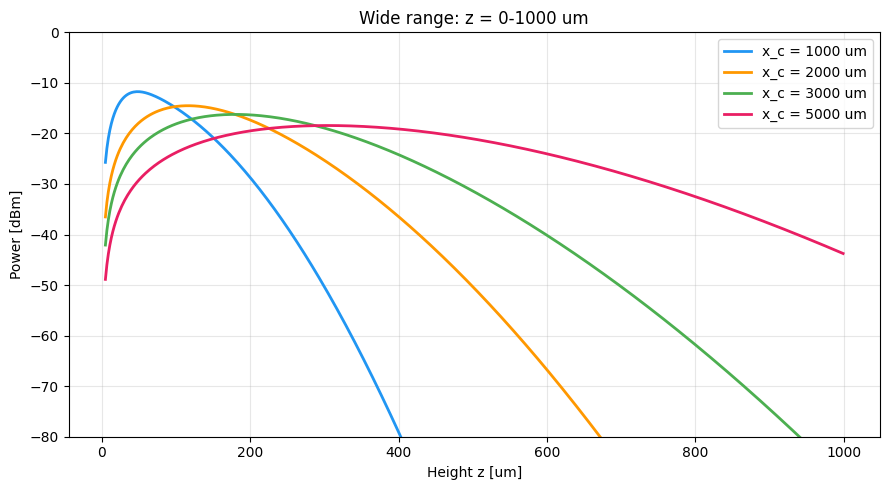

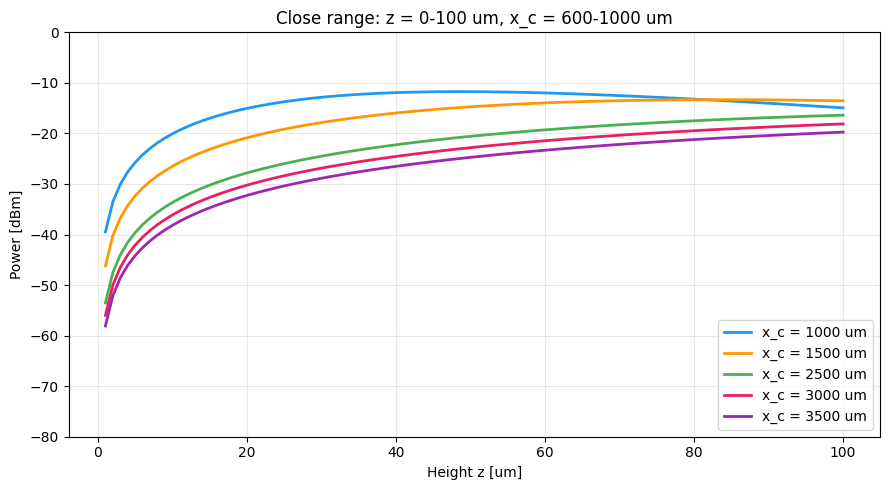

In [8]:
# ============================================================
#  PLOT 1: Wide range  (z = 0..1000 um, x_c = 1..5 mm)
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

z_arr = np.arange(5, 1001, 2)
for x_um, c in [(1000,'#2196F3'), (2000,'#FF9800'), (3000,'#4CAF50'), (5000,'#E91E63')]:
    dBm_arr = np.array([coupling(z*1e-6, x_um*1e-6)[1] for z in z_arr])
    dBm_arr[~np.isfinite(dBm_arr)] = -80
    ax.plot(z_arr, dBm_arr, lw=2, color=c, label=f'x_c = {x_um} um')

ax.set_xlabel('Height z [um]'); ax.set_ylabel('Power [dBm]')
ax.set_title('Wide range: z = 0-1000 um')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylim(-80, 0)
plt.tight_layout(); plt.show()

# ============================================================
#  PLOT 2: Close range (z = 0..100 um, x_c = 600..1000 um)
# ============================================================
fig2, ax2 = plt.subplots(figsize=(9, 5))

z_close = np.arange(1, 101, 1)
for x_um, c in [(1000,'#2196F3'), (1500,'#FF9800'), (2500,'#4CAF50'), (3000,'#E91E63'), (3500,'#9C27B0')]:
    dBm_arr = np.array([coupling(z*1e-6, x_um*1e-6)[1] for z in z_close])
    dBm_arr[~np.isfinite(dBm_arr)] = -80
    ax2.plot(z_close, dBm_arr, lw=2, color=c, label=f'x_c = {x_um} um')

ax2.set_xlabel('Height z [um]'); ax2.set_ylabel('Power [dBm]')
ax2.set_title('Close range: z = 0-100 um, x_c = 600-1000 um')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_ylim(-80, 0)
plt.tight_layout(); plt.show()

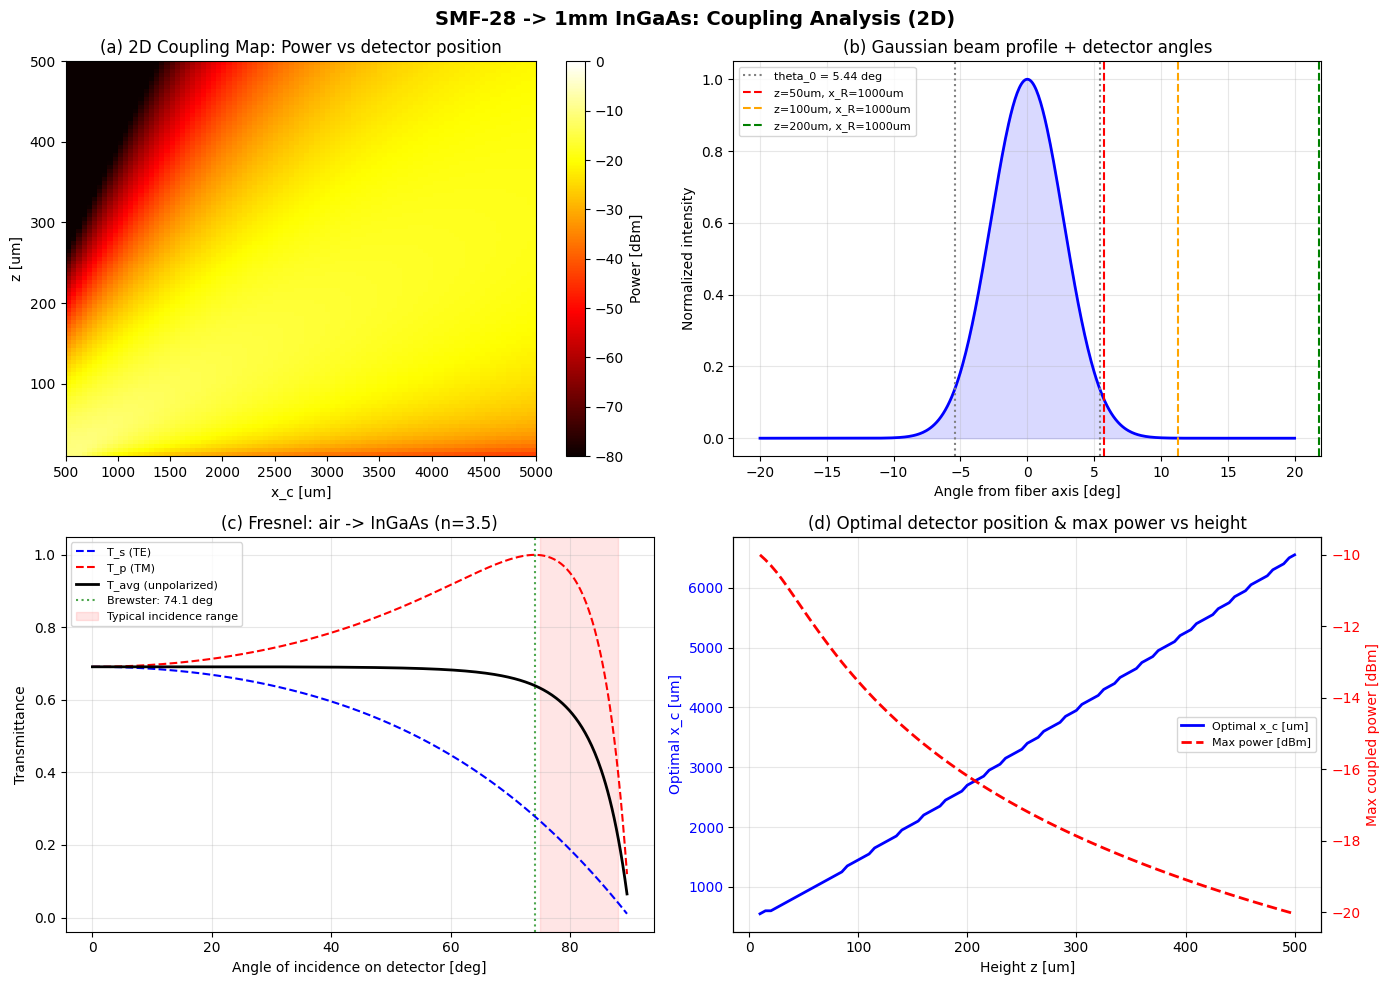


PLOT EXPLANATIONS:
(a) 2D heatmap showing coupled power as a function of both
    detector height (z) and horizontal offset (x_c).
    The bright region is the "sweet spot" for coupling.

(b) Gaussian beam angular intensity profile in air.
    Dashed lines show the minimum angle to reach the detector
    for different heights. Coupling drops exponentially as the
    detector moves further from the beam axis.

(c) Fresnel transmittance at the InGaAs detector surface.
    Shaded region shows the typical incidence angle range.
    Light hits the detector at near-grazing angles (75-88 deg),
    where ~40-60% is transmitted (rest reflected).

(d) For each height z, the optimal x_c position that maximizes
    coupling, and the resulting maximum power. As z increases,
    the optimal x_c shifts further ahead to keep the subtended
    angle within the Gaussian cone.


In [9]:
# ============================================================
#  ADDITIONAL INSIGHT PLOTS
# ============================================================

fig3, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- (a) 2D Heatmap: Power [dBm] vs (z, x_c) ----
ax = axes[0, 0]
z_vals = np.arange(10, 501, 5)
x_vals = np.arange(500, 5001, 50)
power_map = np.full((len(z_vals), len(x_vals)), -80.0)

for i, z_um in enumerate(z_vals):
    for j, x_um in enumerate(x_vals):
        _, db = coupling(z_um * 1e-6, x_um * 1e-6)
        if np.isfinite(db):
            power_map[i, j] = max(db, -80)

im = ax.imshow(power_map, aspect='auto', origin='lower',
               extent=[x_vals[0], x_vals[-1], z_vals[0], z_vals[-1]],
               cmap='hot', vmin=-80, vmax=0)
cb = fig3.colorbar(im, ax=ax, label='Power [dBm]')
ax.set_xlabel('x_c [um]')
ax.set_ylabel('z [um]')
ax.set_title('(a) 2D Coupling Map: Power vs detector position')

# ---- (b) Gaussian beam angular profile ----
ax = axes[0, 1]
th_arr = np.linspace(-20, 20, 500)
I_arr = np.exp(-2 * (np.radians(th_arr) / theta0)**2)
ax.plot(th_arr, I_arr, 'b-', lw=2)
ax.axvline(np.degrees(theta0), color='gray', ls=':', label=f'theta_0 = {np.degrees(theta0):.2f} deg')
ax.axvline(-np.degrees(theta0), color='gray', ls=':')
ax.fill_between(th_arr, I_arr, alpha=0.15, color='blue')

# Mark some detector angles
for z_um, col in [(50, 'red'), (100, 'orange'), (200, 'green')]:
    th_det = np.degrees(np.arctan2(z_um, 500))  # x_c = 500um right edge at 1000um
    ax.axvline(th_det, color=col, ls='--', lw=1.5, label=f'z={z_um}um, x_R=1000um')

ax.set_xlabel('Angle from fiber axis [deg]')
ax.set_ylabel('Normalized intensity')
ax.set_title('(b) Gaussian beam profile + detector angles')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ---- (c) Fresnel transmittance at detector surface ----
ax = axes[1, 0]
angles = np.linspace(0, 89.5, 500)
T_s = []
T_p = []
T_avg = []
for a in angles:
    th = np.radians(a)
    ci = np.cos(th)
    st = (n_air / n_det) * np.sin(th)
    ct = np.sqrt(1 - st**2)
    rs = (n_air*ci - n_det*ct) / (n_air*ci + n_det*ct)
    rp = (n_det*ci - n_air*ct) / (n_det*ci + n_air*ct)
    T_s.append(1 - rs**2)
    T_p.append(1 - rp**2)
    T_avg.append(1 - 0.5*(rs**2 + rp**2))

ax.plot(angles, T_s, 'b--', lw=1.5, label='T_s (TE)')
ax.plot(angles, T_p, 'r--', lw=1.5, label='T_p (TM)')
ax.plot(angles, T_avg, 'k-', lw=2, label='T_avg (unpolarized)')

brewster = np.degrees(np.arctan(n_det / n_air))
ax.axvline(brewster, color='green', ls=':', alpha=0.7, label=f'Brewster: {brewster:.1f} deg')

# Shade the typical detector incidence range
# For z=100um, x_c=1000um: rays at 3.8-11.3 deg from axis -> 78.7-86.2 deg on detector
ax.axvspan(75, 88, alpha=0.1, color='red', label='Typical incidence range')
ax.set_xlabel('Angle of incidence on detector [deg]')
ax.set_ylabel('Transmittance')
ax.set_title(f'(c) Fresnel: air -> InGaAs (n={n_det})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ---- (d) Optimal x_c vs z (where is coupling maximized?) ----
ax = axes[1, 1]
z_scan = np.arange(10, 501, 5)
best_x = []
best_dBm = []
for z_um in z_scan:
    max_db = -999
    max_x = 0
    for x_um in np.arange(100, 10001, 50):
        _, db = coupling(z_um * 1e-6, x_um * 1e-6)
        if db > max_db:
            max_db = db
            max_x = x_um
    best_x.append(max_x)
    best_dBm.append(max_db)

ax2_twin = ax.twinx()
ax.plot(z_scan, best_x, 'b-', lw=2, label='Optimal x_c [um]')
ax2_twin.plot(z_scan, best_dBm, 'r--', lw=2, label='Max power [dBm]')
ax.set_xlabel('Height z [um]')
ax.set_ylabel('Optimal x_c [um]', color='blue')
ax2_twin.set_ylabel('Max coupled power [dBm]', color='red')
ax.tick_params(axis='y', labelcolor='blue')
ax2_twin.tick_params(axis='y', labelcolor='red')
ax.set_title('(d) Optimal detector position & max power vs height')

# Combine legends
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')
ax.grid(True, alpha=0.3)

fig3.suptitle('SMF-28 -> 1mm InGaAs: Coupling Analysis (2D)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('PLOT EXPLANATIONS:')
print('=' * 70)
print('(a) 2D heatmap showing coupled power as a function of both')
print('    detector height (z) and horizontal offset (x_c).')
print('    The bright region is the "sweet spot" for coupling.')
print()
print('(b) Gaussian beam angular intensity profile in air.')
print('    Dashed lines show the minimum angle to reach the detector')
print('    for different heights. Coupling drops exponentially as the')
print('    detector moves further from the beam axis.')
print()
print('(c) Fresnel transmittance at the InGaAs detector surface.')
print('    Shaded region shows the typical incidence angle range.')
print('    Light hits the detector at near-grazing angles (75-88 deg),')
print('    where ~40-60% is transmitted (rest reflected).')
print()
print('(d) For each height z, the optimal x_c position that maximizes')
print('    coupling, and the resulting maximum power. As z increases,')
print('    the optimal x_c shifts further ahead to keep the subtended')
print('    angle within the Gaussian cone.')

2D TOP-DOWN (x-y chip plane, z out of page)
  x: along fiber | y: lateral | z: vertical
theta_0 = 5.44 deg  (I = 13.53% of peak)
2*theta_0 = 10.88 deg  (I = 0.0335% of peak)

Arm length = 7000 um | y margin = 500 um
2*theta_0 cone at WG end (x=7000): y = 1346 um
Waveguide lateral shift y = 1846 um = 1.85 mm
Arm A: y = 1846  |  Arm B: y = 1973  |  pitch = 127 um

Min. clearance detector position (1 mm dia, z > 0):
  x = 6500 um (500 left of WG end)
  y = 1750 um (+500 above cone at x=6500)


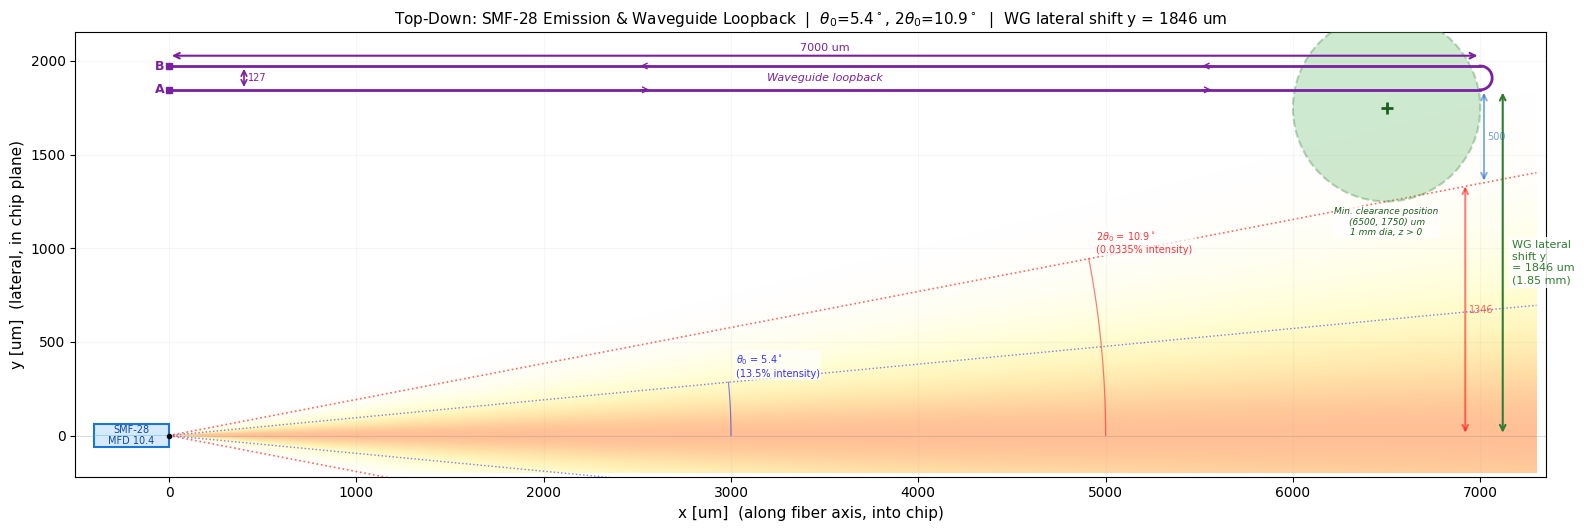


PLACEMENT RULE (y margin = 500 um)
Arm length = 7000 um
2*theta_0 cone at WG end (x=7000): y = 1346 um
Waveguide lateral shift y = 1346 + 500 = 1846 um
  = 1.85 mm from fiber axis

Min. clearance detector position (1 mm dia, z > 0):
  x = 6500 um  (500 left of WG end)
  y = 1750 um  (+500 above cone at x=6500)
  Cone at x=6500: y = 1250 um


In [10]:
# ============================================================
#  2D TOP-DOWN DIAGRAM (x-y chip plane, z = out of page)
#
#  Coordinates:  x = along fiber axis  |  y = lateral  |  z = vertical
#  Waveguide: straight arms + 180-deg Euler bend
#  Margin: 500 um in y only (detector already 500 left of WG end)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---- Fiber parameters (SMF-28, 1550 nm) ----
lam_um   = 1.550
w0_um    = 5.2            # MFD/2
n_core   = 1.4682
n_air    = 1.0
fiber_OD = 125            # um, cladding diameter

theta_fib      = lam_um / (np.pi * n_core * w0_um)
theta0         = np.arcsin(n_core * np.sin(theta_fib) / n_air)
theta0_deg     = np.degrees(theta0)
two_theta0     = 2 * theta0
two_theta0_deg = np.degrees(two_theta0)

G_1th = np.exp(-2)       # intensity at theta_0
G_2th = np.exp(-8)       # intensity at 2*theta_0

# ---- Layout ----
arm_length = 7000         # um (one side of loopback)
wg_pitch   = 127          # um (fiber array pitch)
wg_width   = 0.8          # um
y_margin   = 500          # um - safety gap above 2*theta_0 cone

# x_max = WG end (no extra x buffer; detector is 500 left of this)
x_max  = arm_length
y_cone = x_max * np.tan(two_theta0)      # cone height at WG end
y_min  = y_cone + y_margin                # nearest waveguide

# Waveguide y-positions
y_A    = y_min
y_B    = y_min + wg_pitch
R_180  = wg_pitch / 2

# Min. clearance detector position:
#   500 um left of WG end in x, +500 in y above cone
det_r   = 500             # detector radius (1 mm diameter)
x_det   = arm_length - 500
y_cone_at_xdet = x_det * np.tan(two_theta0)
y_det   = y_cone_at_xdet + y_margin

print('2D TOP-DOWN (x-y chip plane, z out of page)')
print('  x: along fiber | y: lateral | z: vertical')
print('=' * 62)
print(f'theta_0 = {theta0_deg:.2f} deg  (I = {G_1th*100:.2f}% of peak)')
print(f'2*theta_0 = {two_theta0_deg:.2f} deg  (I = {G_2th*100:.4f}% of peak)')
print()
print(f'Arm length = {arm_length} um | y margin = {y_margin} um')
print(f'2*theta_0 cone at WG end (x={x_max}): y = {y_cone:.0f} um')
print(f'Waveguide lateral shift y = {y_min:.0f} um = {y_min/1000:.2f} mm')
print(f'Arm A: y = {y_A:.0f}  |  Arm B: y = {y_B:.0f}  |  pitch = {wg_pitch} um')
print()
print(f'Min. clearance detector position (1 mm dia, z > 0):')
print(f'  x = {x_det} um (500 left of WG end)')
print(f'  y = {y_det:.0f} um (+{y_margin} above cone at x={x_det})')

# ============================================================
#  FIGURE
# ============================================================
fig, ax = plt.subplots(figsize=(16, 8))

# ---- Beam intensity heatmap ----
xg = np.linspace(0.1, x_max + 300, 600)
yg = np.linspace(-200, y_B + 200, 500)
XG, YG = np.meshgrid(xg, yg)
TH = np.arctan2(np.abs(YG), XG)
G  = np.exp(-2 * (TH / theta0)**2)

RGBA = np.zeros((*G.shape, 4))
RGBA[:,:,0] = 1.0
RGBA[:,:,1] = np.clip(1.0 - 0.55 * G, 0.25, 1.0)
RGBA[:,:,2] = 0.08
RGBA[:,:,3] = np.clip(G**0.35 * 0.45, 0, 0.55)

ax.imshow(RGBA, extent=[xg[0], xg[-1], yg[0], yg[-1]],
          origin='lower', aspect='equal', zorder=1,
          interpolation='bilinear')

# ---- Cone lines (dotted, light) ----
xl = np.array([0, x_max + 300])

ax.plot(xl,  xl*np.tan(theta0),  'b:', lw=1.0, alpha=0.5, zorder=3)
ax.plot(xl, -xl*np.tan(theta0),  'b:', lw=1.0, alpha=0.5, zorder=3)

ax.plot(xl,  xl*np.tan(two_theta0), 'r:', lw=1.2, alpha=0.6, zorder=3)
ax.plot(xl, -xl*np.tan(two_theta0), 'r:', lw=1.2, alpha=0.6, zorder=3)

ax.axhline(0, color='gray', ls='-', lw=0.5, alpha=0.3, zorder=2)

# ---- Angle arcs with intensity labels ----
arc_r = 3000
th_a = np.linspace(0, theta0, 60)
ax.plot(arc_r*np.cos(th_a), arc_r*np.sin(th_a), 'b-', lw=0.8, alpha=0.5, zorder=3)
ax.text(arc_r*np.cos(theta0) + 40, arc_r*np.sin(theta0) + 30,
        f'$\\theta_0$ = {theta0_deg:.1f}$^\\circ$\n({G_1th*100:.1f}% intensity)',
        fontsize=7, color='blue', alpha=0.8, zorder=6,
        bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))

arc_r2 = 5000
th_b = np.linspace(0, two_theta0, 60)
ax.plot(arc_r2*np.cos(th_b), arc_r2*np.sin(th_b), 'r-', lw=0.9, alpha=0.5, zorder=3)
ax.text(arc_r2*np.cos(two_theta0) + 40, arc_r2*np.sin(two_theta0) + 30,
        f'$2\\theta_0$ = {two_theta0_deg:.1f}$^\\circ$\n({G_2th*100:.4f}% intensity)',
        fontsize=7, color='red', alpha=0.8, zorder=6,
        bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))

# ---- Fiber ----
fL = 400
ax.add_patch(patches.Rectangle(
    (-fL, -fiber_OD/2), fL, fiber_OD,
    fc='#D6EAFF', ec='#1976D2', lw=1.5, zorder=5))
ax.add_patch(patches.Rectangle(
    (-fL, -w0_um), fL, 2*w0_um,
    fc='#64B5F6', ec='none', zorder=5, alpha=0.5))
ax.text(-fL/2, 0, 'SMF-28\nMFD 10.4', ha='center', va='center',
        fontsize=7, color='#0D47A1', zorder=6)
ax.plot(0, 0, 'ko', ms=3, zorder=6)

# ---- Waveguide loopback (straight arms + 180-deg bend) ----
wc = '#7B1FA2'

ax.plot([0, arm_length], [y_A, y_A], color=wc, lw=2, zorder=5)
ax.plot([0, arm_length], [y_B, y_B], color=wc, lw=2, zorder=5)
t180 = np.linspace(-np.pi/2, np.pi/2, 120)
ax.plot(arm_length + R_180 * np.cos(t180),
        (y_A + y_B) / 2 + R_180 * np.sin(t180),
        color=wc, lw=2, zorder=5)

# Labels A and B + "Waveguide" label in purple
ax.plot(0, y_A, 's', color=wc, ms=5, zorder=6)
ax.plot(0, y_B, 's', color=wc, ms=5, zorder=6)
ax.text(-25, y_A, 'A', ha='right', va='center',
        fontsize=9, color=wc, fontweight='bold', zorder=6)
ax.text(-25, y_B, 'B', ha='right', va='center',
        fontsize=9, color=wc, fontweight='bold', zorder=6)
ax.text(arm_length / 2, (y_A + y_B) / 2,
        'Waveguide loopback', ha='center', va='center',
        fontsize=8, color=wc, style='italic', zorder=6,
        bbox=dict(fc='white', ec='none', alpha=0.75, pad=1))

# Direction arrows
for xp in [2500, 5500]:
    ax.annotate('', xy=(xp+80, y_A), xytext=(xp, y_A),
                arrowprops=dict(arrowstyle='->', color=wc, lw=1), zorder=5)
    ax.annotate('', xy=(xp, y_B), xytext=(xp+80, y_B),
                arrowprops=dict(arrowstyle='->', color=wc, lw=1), zorder=5)

# ---- Detector: translucent green circle (1mm diameter) ----
det_circle = plt.Circle((x_det, y_det), det_r,
                         fc='#66BB6A', ec='#2E7D32', lw=1.5, ls='--',
                         alpha=0.32, zorder=4)
ax.add_patch(det_circle)
ax.plot(x_det, y_det, '+', ms=9, mew=2, color='#1B5E20', zorder=6)
ax.text(x_det, y_det - det_r - 30,
        f'Min. clearance position\n({x_det}, {y_det:.0f}) um\n1 mm dia, z > 0',
        ha='center', va='top', fontsize=6.5, color='#1B5E20',
        style='italic', zorder=6,
        bbox=dict(fc='white', ec='none', alpha=0.75, pad=1))

# ---- DIMENSION ANNOTATIONS ----
arr_kw = dict(arrowstyle='<->', lw=1.5)

# Waveguide lateral shift y
ax.annotate('', xy=(x_max + 120, 0), xytext=(x_max + 120, y_A),
            arrowprops=dict(**arr_kw, color='#2E7D32'), zorder=6)
ax.text(x_max + 170, y_A / 2,
        f'WG lateral\nshift y\n= {y_min:.0f} um\n({y_min/1000:.2f} mm)',
        ha='left', va='center', fontsize=8, color='#2E7D32',
        bbox=dict(fc='white', ec='none', alpha=0.85, pad=2), zorder=7)

# 2*theta_0 cone height at WG end
ax.annotate('', xy=(x_max - 80, 0), xytext=(x_max - 80, y_cone),
            arrowprops=dict(**arr_kw, color='red', alpha=0.5), zorder=6)
ax.text(x_max - 60, y_cone / 2,
        f'{y_cone:.0f}', fontsize=7, color='red', alpha=0.6,
        ha='left', va='center', zorder=6)

# y_margin
ax.annotate('', xy=(x_max + 20, y_cone), xytext=(x_max + 20, y_A),
            arrowprops=dict(**arr_kw, color='#1565C0', alpha=0.5), zorder=6)
ax.text(x_max + 35, (y_cone + y_A) / 2,
        f'{y_margin}', fontsize=7, color='#1565C0', alpha=0.6,
        ha='left', va='center', zorder=6)

# Arm length
ax.annotate('', xy=(0, y_B + 55), xytext=(arm_length, y_B + 55),
            arrowprops=dict(**arr_kw, color=wc), zorder=6)
ax.text(arm_length / 2, y_B + 80,
        f'{arm_length} um', ha='center', fontsize=8, color=wc, zorder=6)

# Pitch
ax.annotate('', xy=(400, y_A), xytext=(400, y_B),
            arrowprops=dict(arrowstyle='<->', color=wc, lw=1.2), zorder=6)
ax.text(420, (y_A + y_B) / 2, f'{wg_pitch}',
        fontsize=7, color=wc, ha='left', va='center', zorder=6)

# ---- Formatting ----
ax.set_xlabel('x [um]  (along fiber axis, into chip)', fontsize=11)
ax.set_ylabel('y [um]  (lateral, in chip plane)', fontsize=11)
ax.set_title(
    f'Top-Down: SMF-28 Emission & Waveguide Loopback  |  '
    f'$\\theta_0$={theta0_deg:.1f}$^\\circ$, '
    f'$2\\theta_0$={two_theta0_deg:.1f}$^\\circ$  |  '
    f'WG lateral shift y = {y_min:.0f} um',
    fontsize=11)

ax.set_xlim(-500, x_max + 350)
ax.set_ylim(-220, y_B + 180)
ax.set_aspect('equal')
ax.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

# ---- Summary ----
print()
print('PLACEMENT RULE (y margin = 500 um)')
print('=' * 62)
print(f'Arm length = {arm_length} um')
print(f'2*theta_0 cone at WG end (x={x_max}): y = {y_cone:.0f} um')
print(f'Waveguide lateral shift y = {y_cone:.0f} + {y_margin} = {y_min:.0f} um')
print(f'  = {y_min/1000:.2f} mm from fiber axis')
print()
print(f'Min. clearance detector position (1 mm dia, z > 0):')
print(f'  x = {x_det} um  (500 left of WG end)')
print(f'  y = {y_det:.0f} um  (+{y_margin} above cone at x={x_det})')
print(f'  Cone at x={x_det}: y = {y_cone_at_xdet:.0f} um')